# Абляционные эксперименты для модели CatBoost

В данном ноутбуке проводится сравнительный анализ нескольких вариантов набора признаков для задачи прогнозирования качества сна. 
Исследуются три постановки: полная модель, модель без прямых лагов качества сна и модель только на признаках активности и режима носимого устройства.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.append(str(Path("..").resolve()))

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from catboost import CatBoostClassifier, Pool

from src.config import (
    MODEL_DATA_PATH,
    RANDOM_STATE,
    CATBOOST_MODEL_DIR,
    REPORT_TABLES_DIR,
    REPORT_TEXT_DIR,
    REPORT_LOGS_DIR,
    CM_FIG_DIR,
    FI_FIG_DIR
)

In [2]:
model_df = pd.read_csv(MODEL_DATA_PATH)

print(model_df.shape)
model_df.head()

(47523, 82)


,SEQN,calendar_date,weekday,dayofweek,window_number,night_number,month,day,dayofyear,target_bad_sleep,...,dur_spt_sleep_min_lag3,dur_spt_wake_IN_min_lag3,dur_spt_wake_LIG_min_lag3,dur_spt_wake_MOD_min_lag3,dur_spt_wake_VIG_min_lag3,dur_day_min_lag3,dur_spt_min_lag3,dur_day_spt_min_lag3,ACC_spt_sleep_mg_lag3,excluded_lag3
0,62161,2000-01-12,Wednesday,4,4,5,1,12,12,1,...,436.0,39.0,2.0,0.0,0.0,876.0,477.0,1353.0,6.743,0.0
1,62161,2000-01-13,Thursday,5,5,6,1,13,13,1,...,403.0,92.0,1.0,0.0,0.0,942.0,496.0,1438.0,3.550,0.0
2,62161,2000-01-14,Friday,6,6,7,1,14,14,1,...,435.0,101.0,10.0,0.0,0.0,896.0,546.0,1442.0,3.243,0.0
3,62161,2000-01-15,Saturday,7,7,8,1,15,15,1,...,425.0,108.0,5.0,0.0,0.0,902.0,538.0,1440.0,5.848,0.0
4,62163,2000-01-12,Wednesday,4,4,5,1,12,12,0,...,332.0,43.0,3.0,0.0,0.0,1004.0,378.0,1382.0,11.669,0.0


In [4]:
print(model_df["target_bad_sleep"].value_counts(normalize=True))

target_bad_sleep
0    0.627928
1    0.372072
Name: proportion, dtype: float64


Базовое разбиение

In [5]:
target_col = "target_bad_sleep"
group_col = "SEQN"

X = model_df.drop(columns=[target_col]).copy()
y = model_df[target_col].astype(int).copy()
groups = model_df[group_col].copy()

Зафиксируем одно разбиение по участникам

Важно: для всех трёх экспериментов используем одно и то же разбиение, чтобы сравнение было честным.

In [6]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train_full = X.iloc[train_idx].copy()
X_test_full = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Train:", X_train_full.shape, y_train.shape)
print("Test :", X_test_full.shape, y_test.shape)
print("Train users:", groups_train.nunique())
print("Test users :", groups_test.nunique())
print("Intersection:", len(set(groups_train).intersection(set(groups_test))))

Train: (37976, 81) (37976,)
Test : (9547, 81) (9547,)
Train users: 10430
Test users : 2608
Intersection: 0


In [7]:
base_drop_cols = ["SEQN", "calendar_date"]

X_train_full = X_train_full.drop(columns=base_drop_cols)
X_test_full = X_test_full.drop(columns=base_drop_cols)

print(X_train_full.shape, X_test_full.shape)

(37976, 79) (9547, 79)


Создаем функцию выбора набора признаков

In [8]:
def select_feature_set(X: pd.DataFrame, feature_mode: str = "full") -> pd.DataFrame:
    X = X.copy()

    if feature_mode == "full":
        return X

    if feature_mode == "no_sleep_quality_lag":
        drop_cols = [
            "sleep_efficiency_lag1",
            "sleep_efficiency_lag2",
            "sleep_efficiency_lag3",
        ]
        return X.drop(columns=[c for c in drop_cols if c in X.columns])

    if feature_mode == "activity_only":
        drop_cols = [
            "sleep_efficiency_lag1", "sleep_efficiency_lag2", "sleep_efficiency_lag3",
            "dur_spt_sleep_min_lag1", "dur_spt_sleep_min_lag2", "dur_spt_sleep_min_lag3",
            "dur_spt_wake_IN_min_lag1", "dur_spt_wake_IN_min_lag2", "dur_spt_wake_IN_min_lag3",
            "dur_spt_wake_LIG_min_lag1", "dur_spt_wake_LIG_min_lag2", "dur_spt_wake_LIG_min_lag3",
            "dur_spt_wake_MOD_min_lag1", "dur_spt_wake_MOD_min_lag2", "dur_spt_wake_MOD_min_lag3",
            "dur_spt_wake_VIG_min_lag1", "dur_spt_wake_VIG_min_lag2", "dur_spt_wake_VIG_min_lag3",
            "dur_spt_min_lag1", "dur_spt_min_lag2", "dur_spt_min_lag3",
            "sleeponset_lag1", "sleeponset_lag2", "sleeponset_lag3",
            "wakeup_lag1", "wakeup_lag2", "wakeup_lag3"
        ]
        return X.drop(columns=[c for c in drop_cols if c in X.columns])

    raise ValueError(f"Unknown feature_mode: {feature_mode}")

In [9]:
for mode in ["full", "no_sleep_quality_lag", "activity_only"]:
    X_tmp = select_feature_set(X_train_full, mode)
    print(mode, "->", X_tmp.shape[1], "features")

full -> 79 features
no_sleep_quality_lag -> 76 features
activity_only -> 52 features


Создаем функцию подбора порога

In [14]:
def evaluate_thresholds(y_true, y_proba, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.10, 0.91, 0.05)

    rows = []

    for thr in thresholds:
        y_pred_thr = (y_proba >= thr).astype(int)

        rows.append({
            "threshold": round(float(thr), 4),
            "precision": precision_score(y_true, y_pred_thr, zero_division=0),
            "recall": recall_score(y_true, y_pred_thr, zero_division=0),
            "f1": f1_score(y_true, y_pred_thr, zero_division=0)
        })

    threshold_df = pd.DataFrame(rows)
    best_row = threshold_df.loc[threshold_df["f1"].idxmax()].copy()

    return threshold_df, best_row

Главная функция эксперимента

In [15]:
def run_catboost_experiment(
    mode: str,
    X_train_base: pd.DataFrame,
    X_test_base: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series
):
    print(f"\n=== Running experiment: {mode} ===")

    X_train = select_feature_set(X_train_base, mode)
    X_test = select_feature_set(X_test_base, mode)

    categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
    cat_features = [X_train.columns.get_loc(col) for col in categorical_cols]

    train_pool = Pool(X_train, y_train, cat_features=cat_features)
    test_pool = Pool(X_test, y_test, cat_features=cat_features)

    model = CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        verbose=100
    )

    model.fit(
        train_pool,
        eval_set=test_pool,
        use_best_model=True
    )

    y_proba = model.predict_proba(test_pool)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba)

    threshold_df, best_row = evaluate_thresholds(y_test, y_proba)
    best_threshold = float(best_row["threshold"])

    y_pred_best = (y_proba >= best_threshold).astype(int)

    precision = precision_score(y_test, y_pred_best, zero_division=0)
    recall = recall_score(y_test, y_pred_best, zero_division=0)
    f1 = f1_score(y_test, y_pred_best, zero_division=0)

    cls_report = classification_report(y_test, y_pred_best, digits=4)
    cm = confusion_matrix(y_test, y_pred_best)

    feature_importance = pd.DataFrame({
        "feature": X_train.columns,
        "importance": model.get_feature_importance()
    }).sort_values("importance", ascending=False)

    # Сохранение таблицы порогов
    threshold_df.to_csv(REPORT_TABLES_DIR / f"catboost_thresholds_{mode}.csv", index=False)

    # Сохранение importance
    feature_importance.to_csv(
        REPORT_TABLES_DIR / f"catboost_feature_importance_{mode}.csv",
        index=False
    )

    # Сохранение classification report
    with open(REPORT_TEXT_DIR / f"classification_report_catboost_{mode}.txt", "w", encoding="utf-8") as f:
        f.write(cls_report)

    # Сохранение лога
    log_text = f"""
Experiment: {mode}
Features count: {X_train.shape[1]}
Categorical columns: {categorical_cols}
Best threshold: {best_threshold:.2f}
Best iteration: {model.get_best_iteration()}
ROC-AUC: {roc_auc:.4f}
Precision: {precision:.4f}
Recall: {recall:.4f}
F1-score: {f1:.4f}
"""
    with open(REPORT_LOGS_DIR / f"run_{mode}.txt", "w", encoding="utf-8") as f:
        f.write(log_text.strip())

    # Сохранение модели
    model.save_model(CATBOOST_MODEL_DIR / f"catboost_{mode}.cbm")

    # Сохранение test predictions
    pred_df = X_test.copy()
    pred_df["y_true"] = y_test.values
    pred_df["y_proba"] = y_proba
    pred_df[f"y_pred_thr_{str(best_threshold).replace('.', '')}"] = y_pred_best
    pred_df.to_csv(REPORT_TABLES_DIR / f"catboost_test_predictions_{mode}.csv", index=False)

    # Матрица ошибок
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax)
    plt.title(f"CatBoost confusion matrix: {mode}, thr={best_threshold:.2f}")
    plt.savefig(CM_FIG_DIR / f"catboost_{mode}_confusion_matrix.png", dpi=200, bbox_inches="tight")
    plt.show()

    # График важности признаков
    top_n = min(20, len(feature_importance))
    fi_top = feature_importance.head(top_n).sort_values("importance")

    plt.figure(figsize=(10, 8))
    plt.barh(fi_top["feature"], fi_top["importance"])
    plt.title(f"Top-{top_n} feature importance: {mode}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.savefig(FI_FIG_DIR / f"catboost_{mode}_top{top_n}.png", dpi=200, bbox_inches="tight")
    plt.show()

    result_row = {
        "mode": mode,
        "features_count": X_train.shape[1],
        "best_threshold": best_threshold,
        "roc_auc": roc_auc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "best_iteration": model.get_best_iteration()
    }

    print("\nResult:")
    print(pd.Series(result_row))
    print("\nClassification report:")
    print(cls_report)

    return {
        "result_row": result_row,
        "threshold_df": threshold_df,
        "feature_importance": feature_importance,
        "classification_report": cls_report
    }

Запускаем три эксперимента


=== Running experiment: full ===
0:	test: 0.7174443	best: 0.7174443 (0)	total: 28.9ms	remaining: 14.4s
100:	test: 0.7446270	best: 0.7446270 (100)	total: 3.27s	remaining: 12.9s
200:	test: 0.7459298	best: 0.7459800 (199)	total: 6.48s	remaining: 9.64s
300:	test: 0.7451359	best: 0.7460672 (252)	total: 9.7s	remaining: 6.42s
400:	test: 0.7451863	best: 0.7460672 (252)	total: 13s	remaining: 3.2s
499:	test: 0.7443662	best: 0.7460672 (252)	total: 16.2s	remaining: 0us

bestTest = 0.7460671818
bestIteration = 252

Shrink model to first 253 iterations.


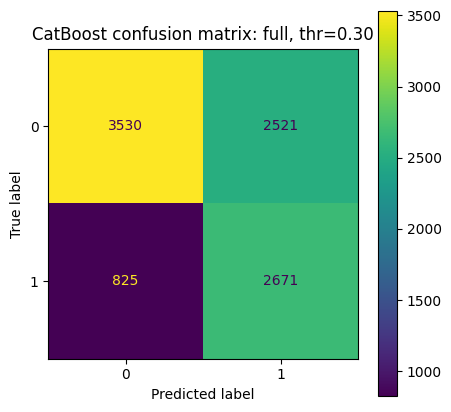

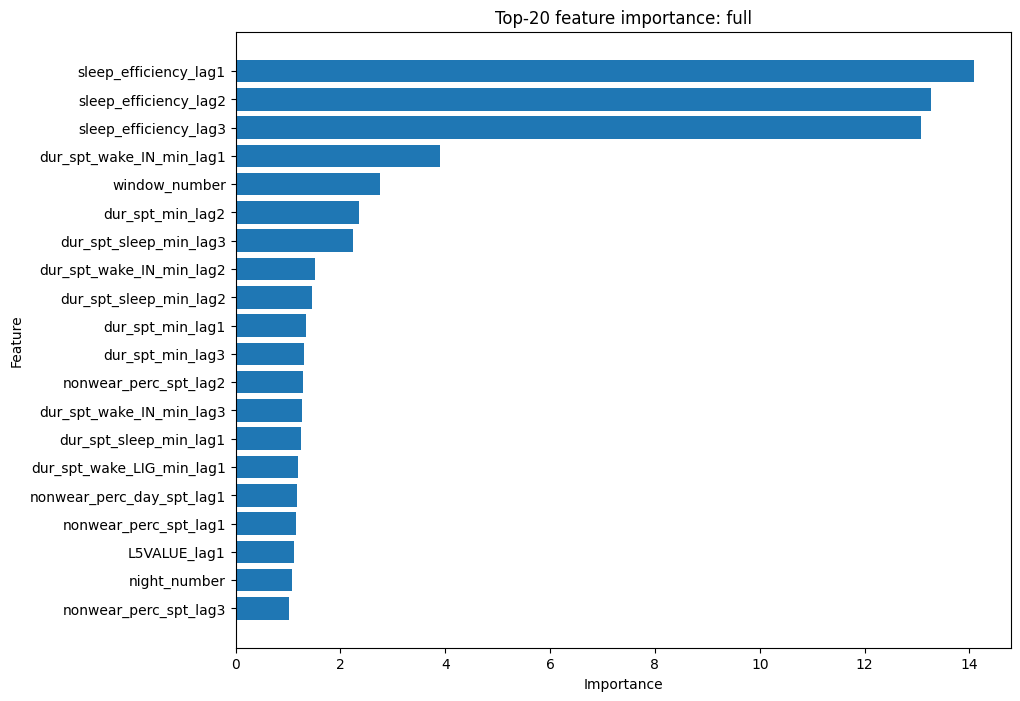


Result:
mode                  full
features_count          79
best_threshold         0.3
roc_auc           0.746067
precision         0.514445
recall            0.764016
f1_score          0.614871
best_iteration         252
dtype: object

Classification report:
              precision    recall  f1-score   support

           0     0.8106    0.5834    0.6785      6051
           1     0.5144    0.7640    0.6149      3496

    accuracy                         0.6495      9547
   macro avg     0.6625    0.6737    0.6467      9547
weighted avg     0.7021    0.6495    0.6552      9547


=== Running experiment: no_sleep_quality_lag ===
0:	test: 0.7035774	best: 0.7035774 (0)	total: 27.3ms	remaining: 13.6s
100:	test: 0.7449163	best: 0.7449163 (100)	total: 3.14s	remaining: 12.4s
200:	test: 0.7462319	best: 0.7463876 (179)	total: 6.21s	remaining: 9.24s
300:	test: 0.7461724	best: 0.7463876 (179)	total: 9.51s	remaining: 6.28s
400:	test: 0.7459892	best: 0.7463876 (179)	total: 12.8s	remaining: 3.16

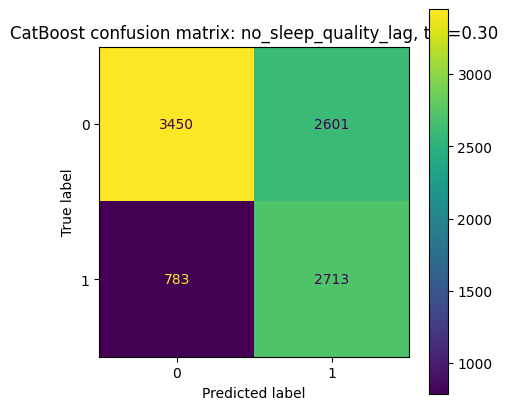

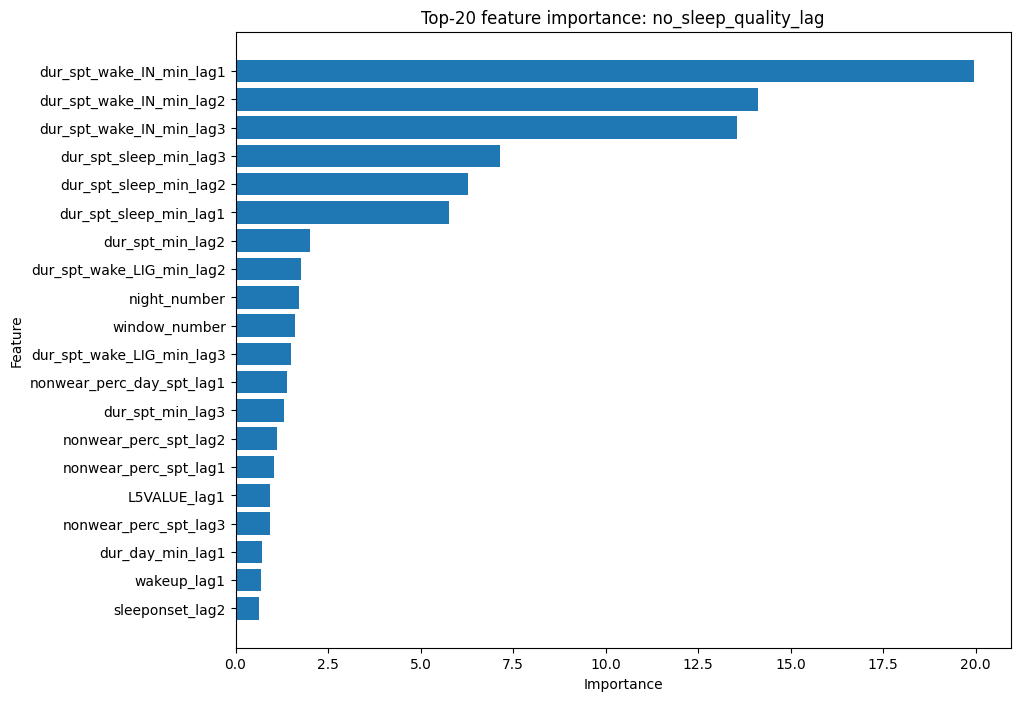


Result:
mode              no_sleep_quality_lag
features_count                      76
best_threshold                     0.3
roc_auc                       0.746388
precision                     0.510538
recall                         0.77603
f1_score                      0.615891
best_iteration                     179
dtype: object

Classification report:
              precision    recall  f1-score   support

           0     0.8150    0.5702    0.6709      6051
           1     0.5105    0.7760    0.6159      3496

    accuracy                         0.6455      9547
   macro avg     0.6628    0.6731    0.6434      9547
weighted avg     0.7035    0.6455    0.6508      9547


=== Running experiment: activity_only ===
0:	test: 0.5454592	best: 0.5454592 (0)	total: 29.7ms	remaining: 14.8s
100:	test: 0.5958758	best: 0.5966323 (86)	total: 3.08s	remaining: 12.2s
200:	test: 0.5986488	best: 0.5986488 (200)	total: 6.18s	remaining: 9.19s
300:	test: 0.5992017	best: 0.6002154 (269)	total: 9.29s	

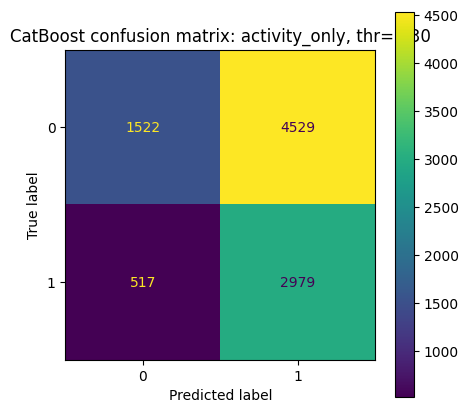

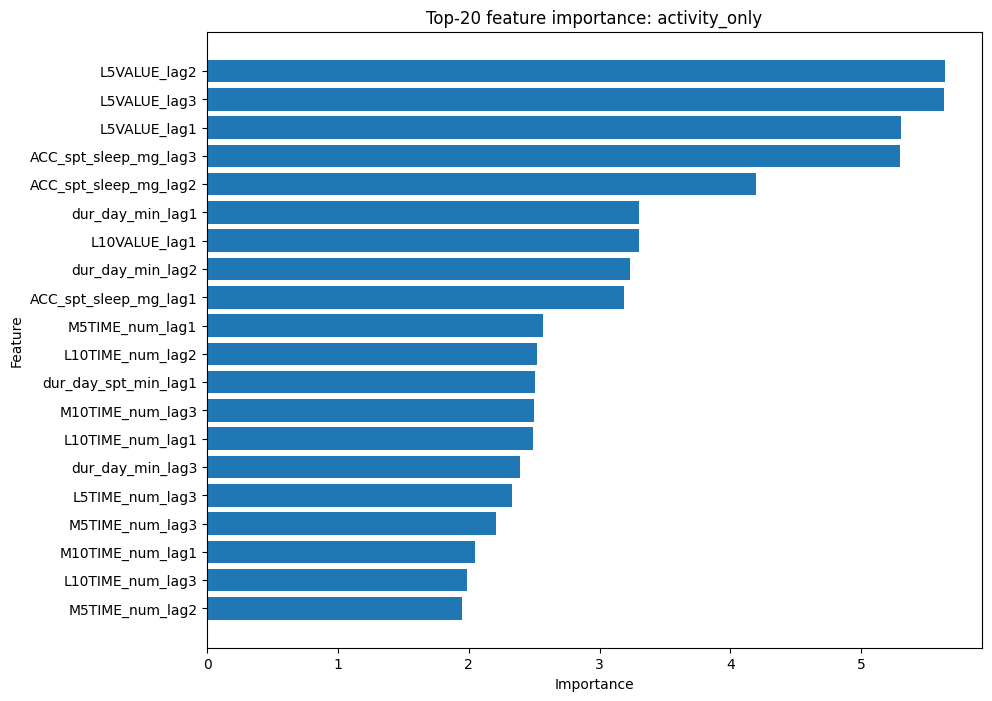


Result:
mode              activity_only
features_count               52
best_threshold              0.3
roc_auc                0.600371
precision              0.396777
recall                 0.852117
f1_score               0.541439
best_iteration              428
dtype: object

Classification report:
              precision    recall  f1-score   support

           0     0.7464    0.2515    0.3763      6051
           1     0.3968    0.8521    0.5414      3496

    accuracy                         0.4715      9547
   macro avg     0.5716    0.5518    0.4589      9547
weighted avg     0.6184    0.4715    0.4368      9547



In [16]:
results = {}

for mode in ["full", "no_sleep_quality_lag", "activity_only"]:
    results[mode] = run_catboost_experiment(
        mode=mode,
        X_train_base=X_train_full,
        X_test_base=X_test_full,
        y_train=y_train,
        y_test=y_test
    )

In [17]:
ablation_comparison = pd.DataFrame([
    results["full"]["result_row"],
    results["no_sleep_quality_lag"]["result_row"],
    results["activity_only"]["result_row"]
]).round(4)

ablation_comparison

,mode,features_count,best_threshold,roc_auc,precision,recall,f1_score,best_iteration
0,full,79,0.3,0.7461,0.5144,0.7640,0.6149,252
1,no_sleep_quality_lag,76,0.3,0.7464,0.5105,0.7760,0.6159,179
2,activity_only,52,0.3,0.6004,0.3968,0.8521,0.5414,428


In [18]:
ablation_comparison.to_csv(REPORT_TABLES_DIR / "ablation_comparison.csv", index=False)

Смотрим топ-10 признаков

In [19]:
results["full"]["feature_importance"].head(10)

,feature,importance
7,sleep_efficiency_lag1,14.078878
31,sleep_efficiency_lag2,13.270499
55,sleep_efficiency_lag3,13.083151
22,dur_spt_wake_IN_min_lag1,3.907584
2,window_number,2.760119
51,dur_spt_min_lag2,2.354756
69,dur_spt_sleep_min_lag3,2.239605
46,dur_spt_wake_IN_min_lag2,1.512993
45,dur_spt_sleep_min_lag2,1.463917
27,dur_spt_min_lag1,1.348698


In [20]:
results["no_sleep_quality_lag"]["feature_importance"].head(10)

,feature,importance
21,dur_spt_wake_IN_min_lag1,19.943692
44,dur_spt_wake_IN_min_lag2,14.117796
67,dur_spt_wake_IN_min_lag3,13.549180
66,dur_spt_sleep_min_lag3,7.140299
43,dur_spt_sleep_min_lag2,6.271554
20,dur_spt_sleep_min_lag1,5.779271
49,dur_spt_min_lag2,2.021511
45,dur_spt_wake_LIG_min_lag2,1.764452
3,night_number,1.710509
2,window_number,1.609393


In [21]:
results["activity_only"]["feature_importance"].head(10)

,feature,importance
25,L5VALUE_lag2,5.640453
40,L5VALUE_lag3,5.632297
10,L5VALUE_lag1,5.305336
50,ACC_spt_sleep_mg_lag3,5.292456
35,ACC_spt_sleep_mg_lag2,4.193795
18,dur_day_min_lag1,3.301454
14,L10VALUE_lag1,3.297680
33,dur_day_min_lag2,3.233957
20,ACC_spt_sleep_mg_lag1,3.185391
13,M5TIME_num_lag1,2.568189
